In [32]:
import numpy as np
import qutip as qt
from Quantum_dot_qutip import *
from tqdm import tqdm
import pickle
from entropy import RDM_entropy
import random as rand

N=10
d=2**N

exact_model = Quantum_dot(2)
analog_model = analog_QD(exact_model, h=0.2,J=0.2, theta=0.1, DeltaE=0.5)

def rank_k_haar_state(rank,seed=None):
    #initial qutip state
    state=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    for _ in range(rank-1):
    #subsystems with 2 & 8 qubits
        state+=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    return state.unit() #normalization

def rank_k_state(rank,seed=None):
    rand.seed(seed)
    result = qt.Qobj(np.zeros((d,1)), dims=[[2]*10, [1]])
    for _ in range(rank):
    #initial qutip state
        state = qt.basis([2]*10)
        #implement a random pauli operator on each qubit
        pauli_ops = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
        op = qt.tensor([rand.choice(pauli_ops) for _ in range(10)])
        state = op * state
        result += state
    return result.unit() #normalization

def thermal_state(temperature):
    computation_basis =[[0,0,0,0],[0,1,0,1],[1,0,1,0],[1,1,1,1]]
    H=qt.Qobj(np.zeros((d,d)), dims=[[2]*10]*2)
    for i in range(4):
        H-=qt.tensor([qt.sigmaz() if j == i else qt.qeye(2) for j in range(10)])
    # psi_T = qt.Qobj(np.zeros(d), dims=[2]*10)
    psi_T = qt.Qobj(np.zeros((d,1)), dims=[[2]*10, [1]])
    for A_subsys in computation_basis:
        psi_T += qt.tensor(qt.basis([2]*4,A_subsys),qt.basis([2]*6))
    # Calculate the thermal state using the Gibbs distribution
    psi_T = (-H * temperature).expm()*psi_T
    # Normalize the density matrix
    return psi_T.unit()

def analog_error(initial_state, analog_model : analog_QD,time):
    # Compute the error between the initial state and the analog model
    exact_states=qt.mesolve(analog_model.exact_model.H,initial_state, time).states
    analog_states=qt.mesolve(analog_model.H,initial_state, time).states
    errors = [exact_states[i]-analog_states[i] for i in range(len(time))]
    error_norms = [err.norm('l2') for err in errors]
    return error_norms

seed=123

entropy_list = []
error_list = []
# initial_state = qt.rand_ket([2]*10,seed = 123)
# initial_state = qt.basis([2]*10)
for temperature in tqdm(range(60)):
    state = thermal_state((temperature)*0.008)
    entropy_list.append(RDM_entropy(state.full(),8)[-1]) #entropy of 8-qubit subsystem
    error_list.append(analog_error(state,analog_model,np.linspace(0, 1.5, 4)))


100%|██████████| 60/60 [00:02<00:00, 25.11it/s]


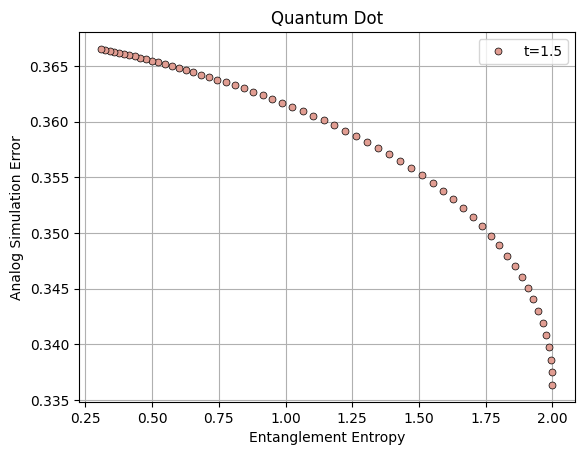

In [33]:
plt.plot(entropy_list,np.array(error_list)[:,3],color='0.3', marker='o', markersize=5, mfc='#e19d92', mec='k', linestyle='', markeredgewidth=0.5,label='t=1.5')
# plt.plot(entropy_list,np.array(error_list)[:,2],color='0.3', marker='o', markersize=5, mfc='#f7c6c2', mec='k', linestyle='', markeredgewidth=0.5,label='t=1.0')
# plt.plot(entropy_list,np.array(error_list)[:,1],color='0.3', marker='o', markersize=5, mfc='#fcd0cb', mec='k', linestyle='', markeredgewidth=0.5,label='t=0.5')
plt.xlabel('Entanglement Entropy')
plt.ylabel('Analog Simulation Error')
plt.title('Quantum Dot')
plt.legend()
plt.grid()
plt.savefig('./Figures/QD_entropy_error.pdf',bbox_inches='tight',dpi=600)
plt.show()